# CUSTOMER CHURN PREDICTION SYSTEM


## Problem Statement
The project aims to predict customer churn in an e-commerce platform using machine learning techniques. It analyzes customer behavior data to identify users who are likely to stop using the service, helping businesses improve customer retention.

In [173]:
## Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [174]:
## Load Dataset

# loaded the ecommerce customer dataset using pandas.
df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [175]:
## Data Understanding

In [176]:
# Here I checked dataset structure, missing values, and data types.
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [177]:
## Step 4: Exploratory Data Analysis (EDA)

#In this step, I analyzed the data to understand patterns and relationships between features.

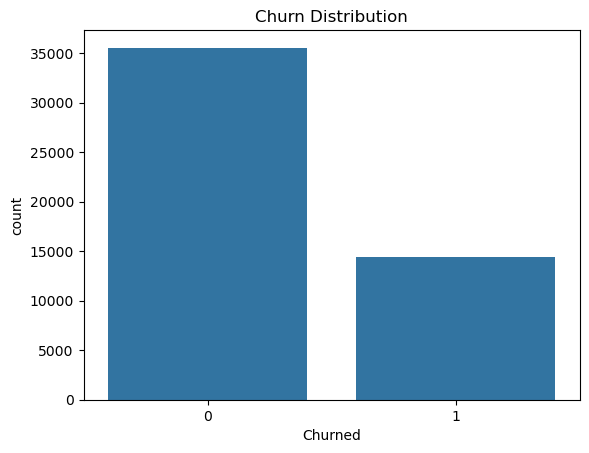

In [178]:
sns.countplot(x="Churned", data=df)
plt.title("Churn Distribution")
plt.show()

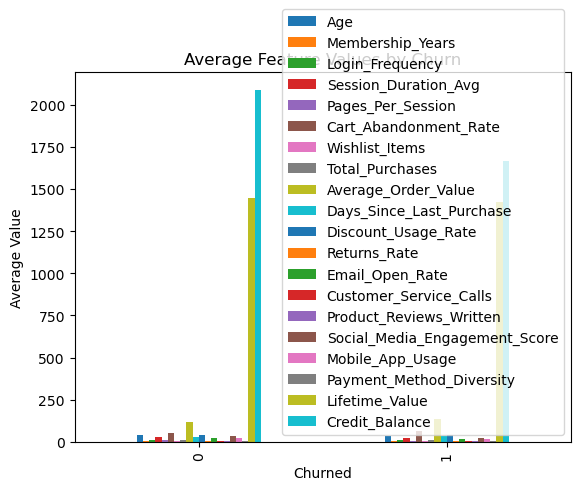

In [179]:
## Feature Comparison

# Here I compared average feature values for churned and non-churned customers to find useful patterns.
df.groupby("Churned").mean(numeric_only=True).plot(kind="bar")
plt.title("Average Feature Values by Churn")
plt.ylabel("Average Value")
plt.show()

In [180]:
## Correlation Heatmap

# Here I checked how different numerical features are related to each other using correlation.
# This helps in understanding important features for prediction.

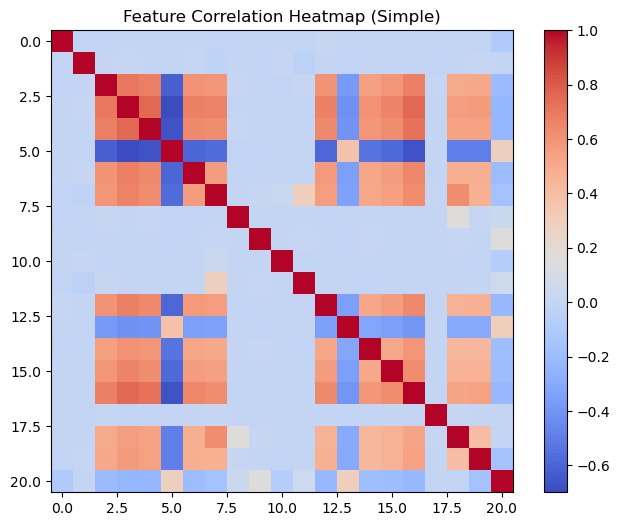

In [181]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Feature Correlation Heatmap (Simple)")
plt.show()

In [182]:
df.isnull().sum().sum()

np.int64(49081)

In [183]:
# fill missing values
df = df.fillna(df.mean(numeric_only = True))

In [184]:
from sklearn.preprocessing import LabelEncoder

In [185]:
le = LabelEncoder()

In [186]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [187]:
# encode categorical columns

In [188]:
# Split Data
X = df.drop("Churned", axis=1)
y = df["Churned"]

In [189]:
## Model Training

In [190]:
from sklearn.model_selection import train_test_split

In [191]:
## Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [192]:
from sklearn.preprocessing import StandardScaler

In [193]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [194]:
## Model Training

In [195]:
from sklearn.linear_model import LogisticRegression

In [196]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [197]:
## Prediction
y_pred = model.predict(X_test)

In [198]:
## Model Evaluation

# Here I checked model performance using accuracy, confusion matrix and classification report.

In [199]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [200]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7763

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85      7112
           1       0.69      0.41      0.51      2888

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.68     10000
weighted avg       0.76      0.78      0.76     10000


Confusion Matrix:
 [[6577  535]
 [1702 1186]]


In [201]:
## Step 8: Sample prediction

# Testing model on a sample input.

In [202]:
print("\nExample Predictions:")
print(y_pred[:5])


Example Predictions:
[1 0 0 0 0]


## Conclusion

In this project, I built a machine learning model to predict customer churn in an e-commerce platform.

I performed Exploratory Data Analysis (EDA) to understand patterns in customer behavior.

Then I applied Logistic Regression to classify whether a customer will churn or not.

This project shows how machine learning can help businesses improve customer retention and decision making.